<a href="https://colab.research.google.com/github/saachi-surana/Path2Profit/blob/main/Path2Profit_SMOTE_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
dataset = pd.read_csv('online_shoppers_intention.csv')

In [5]:
dataset.shape

(12330, 18)

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [7]:
dataset.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [8]:
dataset.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


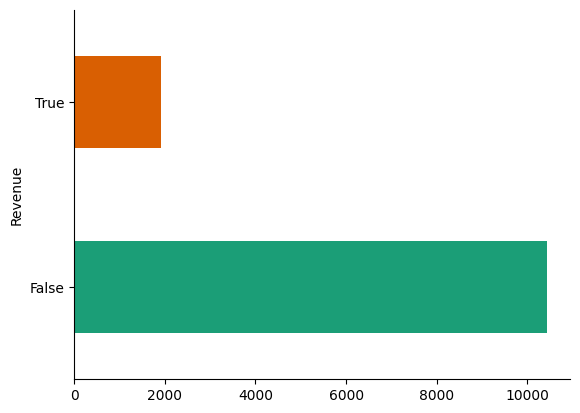

In [9]:
dataset.groupby('Revenue').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [10]:
dataset.dtypes

,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


In [11]:
dataset['OperatingSystems'] = dataset['OperatingSystems'].astype('str')
dataset['Browser'] = dataset['Browser'].astype('str')
dataset['Region'] = dataset['Region'].astype('str')
dataset['TrafficType'] = dataset['TrafficType'].astype('str')
dataset['Weekend'] = dataset['Weekend'].astype('str')
dataset['Revenue'] = dataset['Revenue'].astype('str')

In [12]:
dataset.dtypes

,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


In [13]:
dataset['Revenue'].value_counts()

,count
Revenue,
False,10422
True,1908


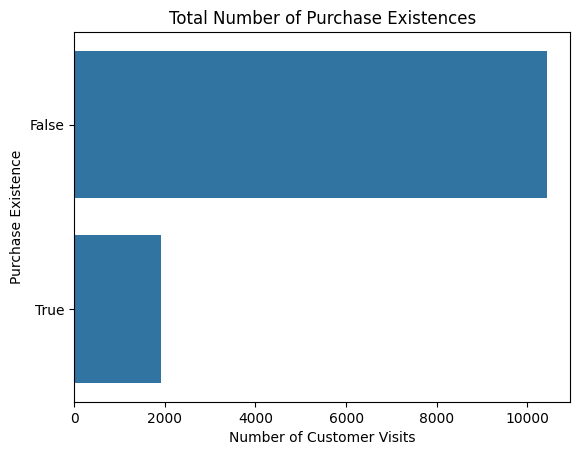

In [14]:
sns.countplot(data = dataset['Revenue'])
plt.xlabel('Number of Customer Visits')
plt.ylabel('Purchase Existence')
plt.title('Total Number of Purchase Existences')
plt.show()

In [15]:
obj_set = [f for f in dataset.columns if dataset.dtypes[f] == 'object']
obj_set = dataset[obj_set]

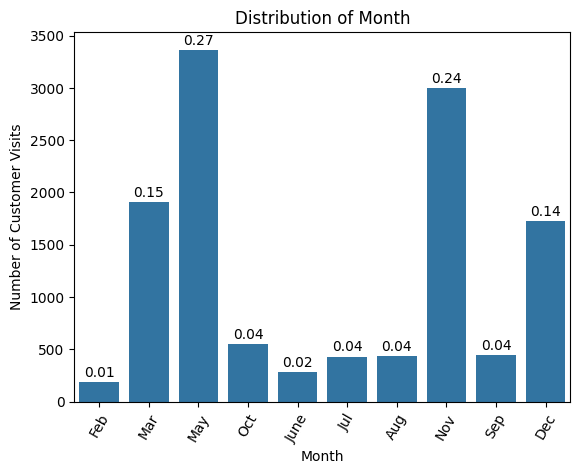

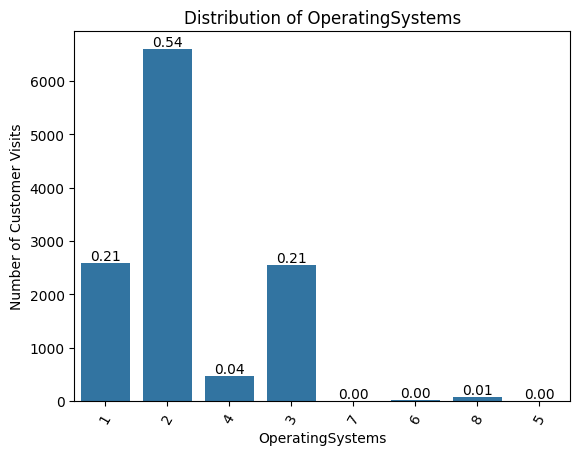

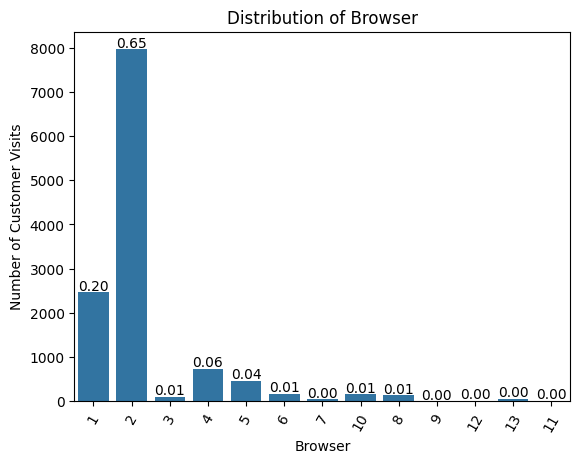

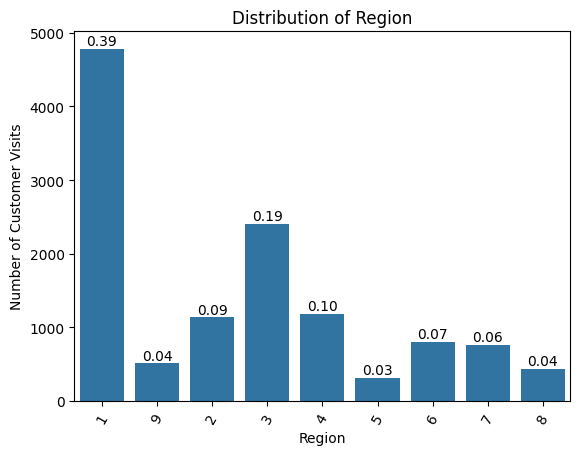

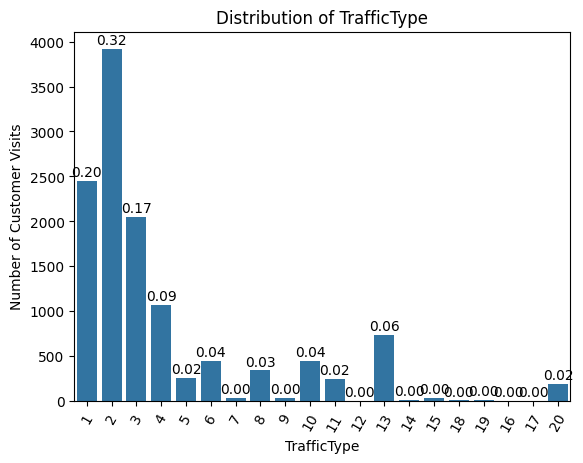

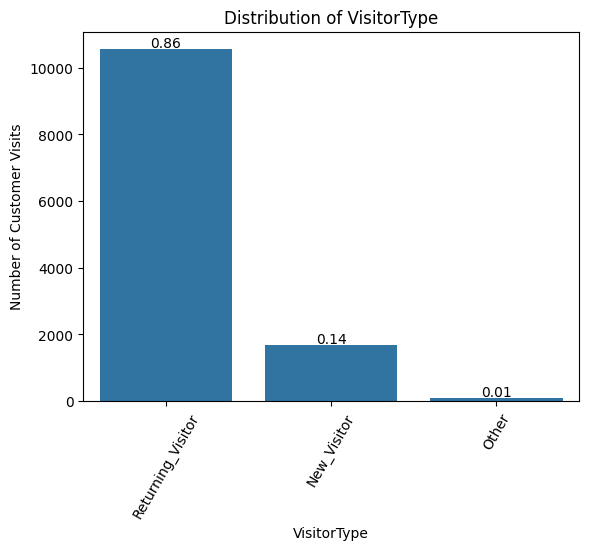

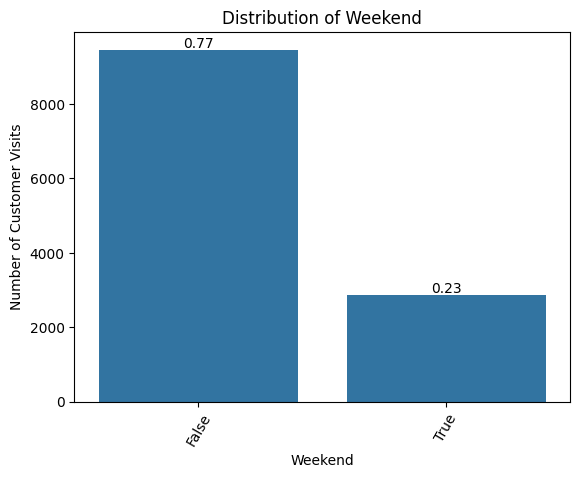

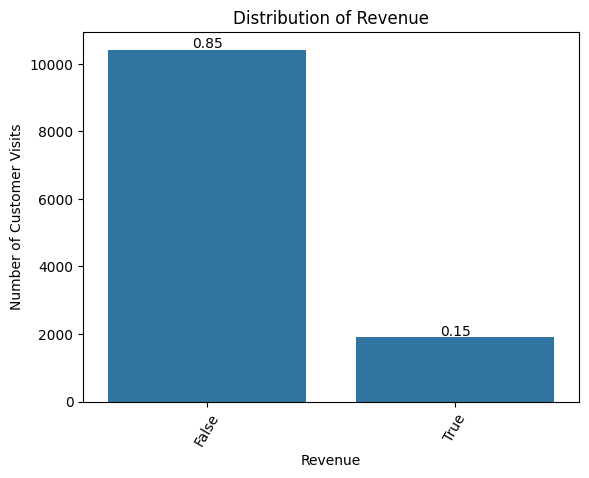

In [16]:
for var in obj_set.columns:
    ax = sns.countplot(x = dataset[var], data = dataset)
    total = float(len(dataset[var]))
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width() / 2.,
                height + 50,
                '{:1.2f}'.format(height/total),
                ha="center")
    plt.title('Distribution of ' + str(var))
    plt.ylabel('Number of Customer Visits')
    plt.xticks(rotation = 60)
    plt.show()

In [17]:
for var in obj_set.columns:
    print(dataset[var].value_counts())

Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64
OperatingSystems
2    6601
1    2585
3    2555
4     478
8      79
6      19
7       7
5       6
Name: count, dtype: int64
Browser
2     7961
1     2462
4      736
5      467
6      174
10     163
8      135
3      105
13      61
7       49
12      10
11       6
9        1
Name: count, dtype: int64
Region
1    4780
3    2403
4    1182
2    1136
6     805
7     761
9     511
8     434
5     318
Name: count, dtype: int64
TrafficType
2     3913
1     2451
3     2052
4     1069
13     738
10     450
6      444
8      343
5      260
11     247
20     198
9       42
7       40
15      38
19      17
14      13
18      10
16       3
12       1
17       1
Name: count, dtype: int64
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64
Weekend
False    9462
True     2868
Na

In [18]:
num_set = [f for f in dataset.columns if dataset.dtypes[f] != 'object']
num_set = dataset[num_set]

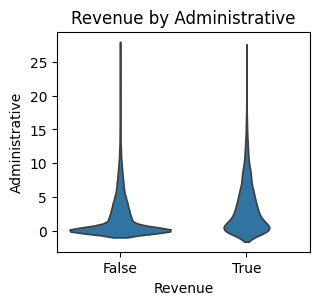

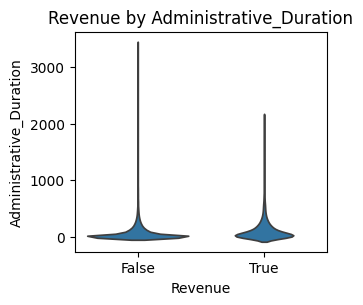

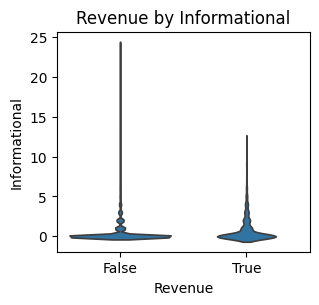

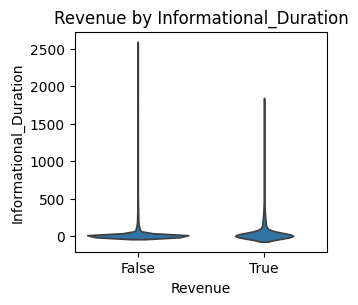

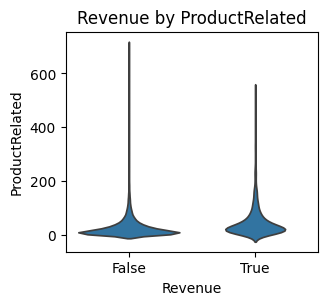

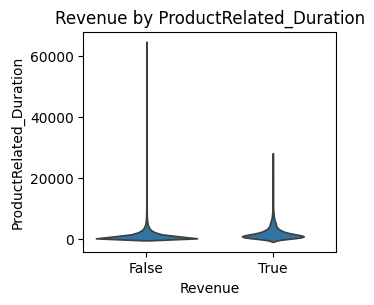

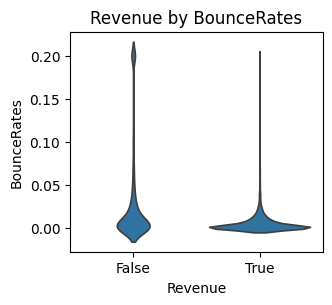

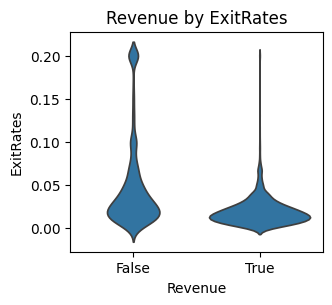

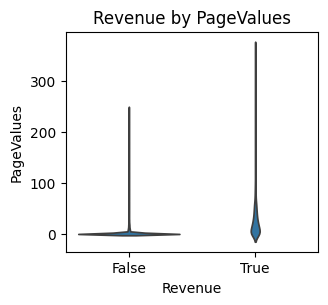

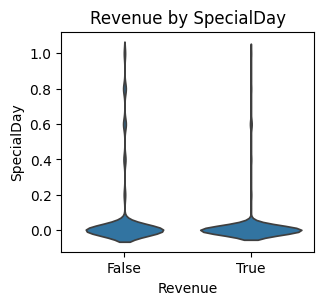

In [19]:
num_all_columns = ['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

for i in range(len(num_all_columns)):
    plt.figure(figsize=(15, 20))
    plt.subplot(6, 4, i + 1)
    sns.violinplot(x=dataset['Revenue'], y=dataset[num_all_columns[i]], data=dataset, inner=None)
    plt.title('Revenue by {}'.format(num_all_columns[i]))
    plt.show()

/tmp/ipykernel_2135/3696331954.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(num_set[num_all_columns[i]])
/tmp/ipykernel_2135/3696331954.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(num_set[num_all_columns[i]])
/tmp/ipykernel_2135/3696331954.py:9: UserWarning: 

`distplot` is a depr

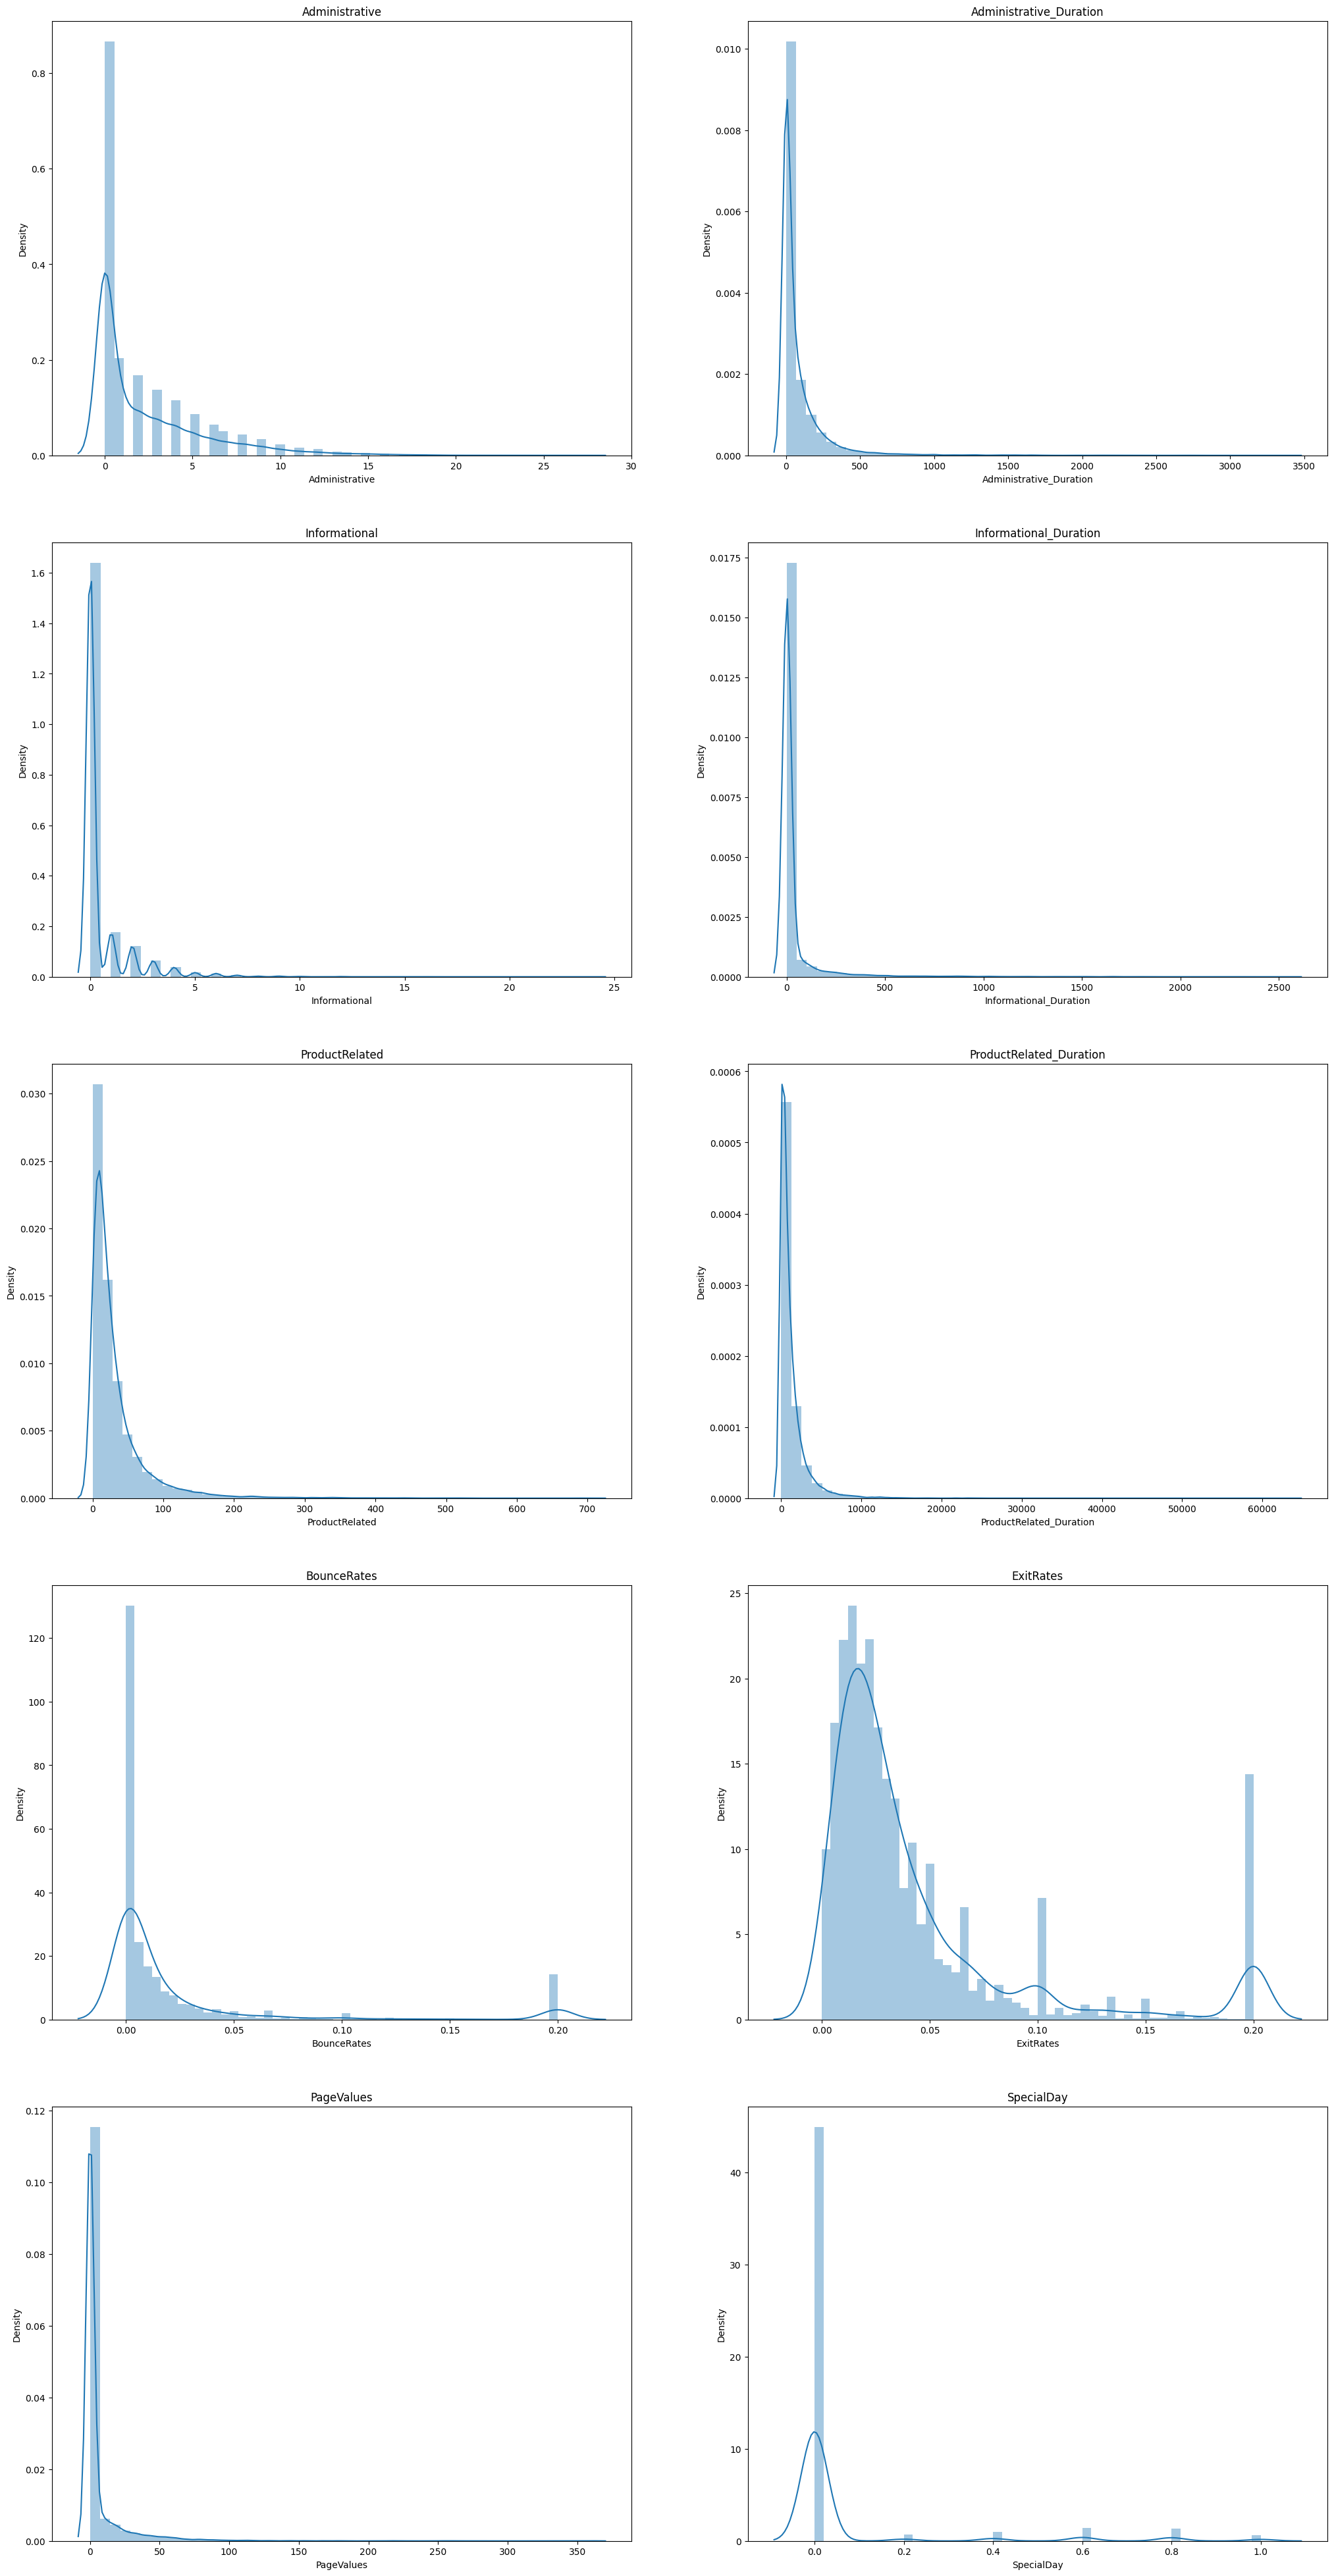

In [20]:
num_all_columns = ['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

plt.figure(figsize=(25, 60))

for i in range(len(num_all_columns)):
    plt.subplot(6, 2, i + 1)
    sns.distplot(num_set[num_all_columns[i]])
    plt.title(num_all_columns[i])

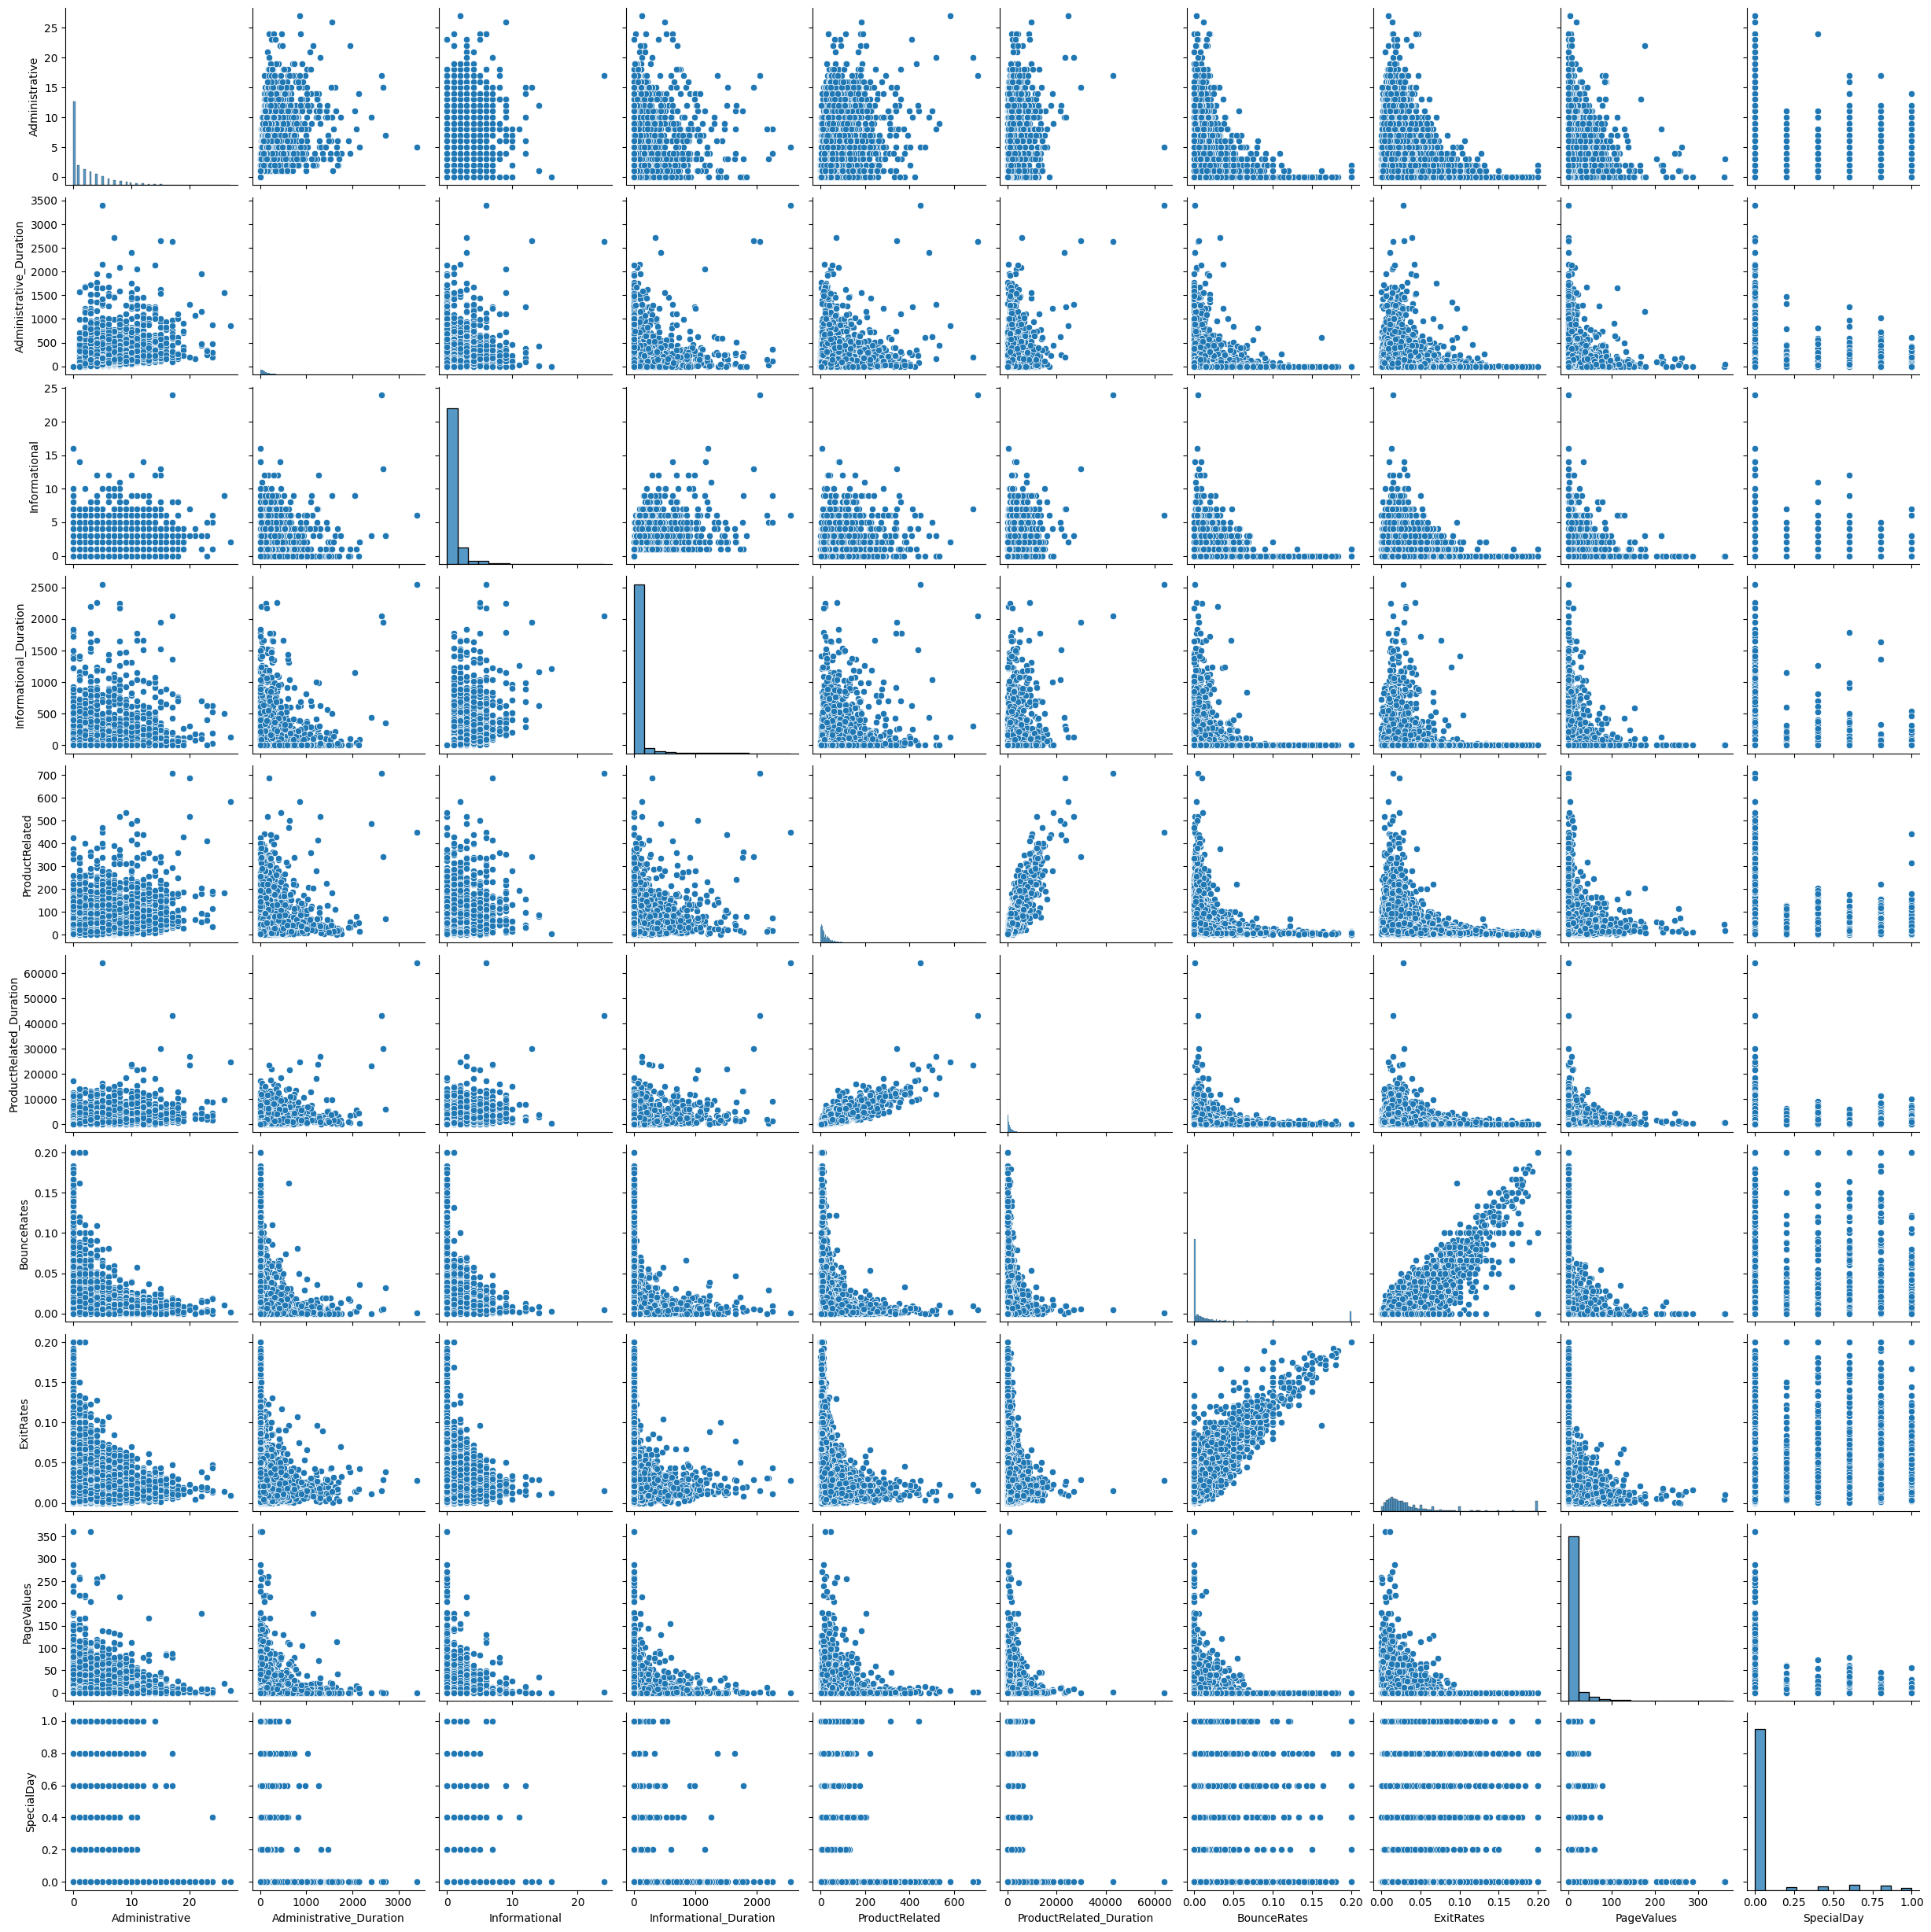

In [21]:
sns.pairplot(num_set)
plt.show()

(10, 10)


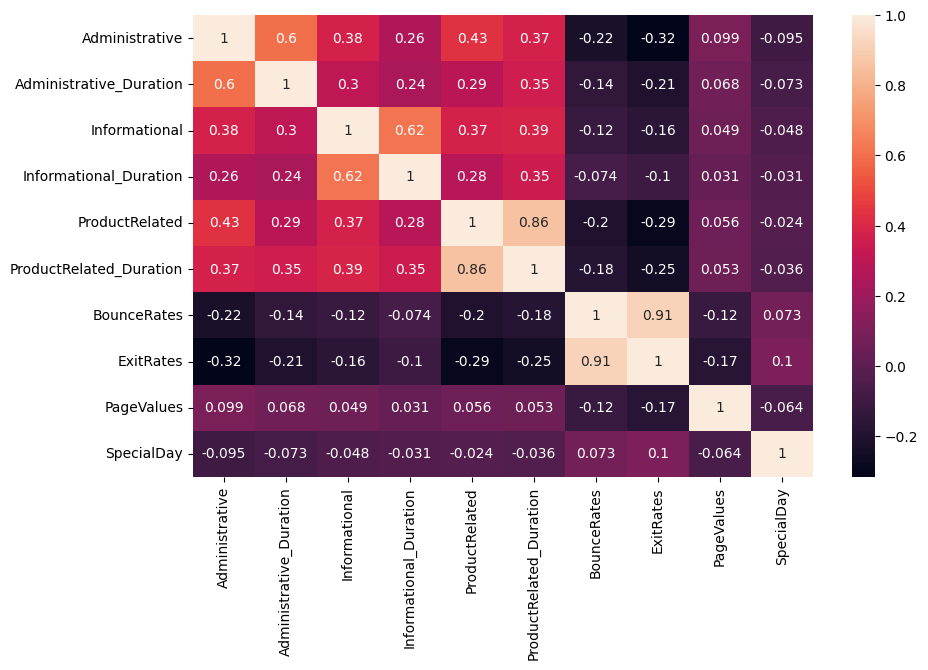

In [22]:
corr_matrix = round(num_set.corr(), 3)
print(corr_matrix.shape)
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True)
plt.show()

In [24]:
new_num_set = num_set.drop(columns=['ProductRelated', 'ExitRates', 'Informational'])

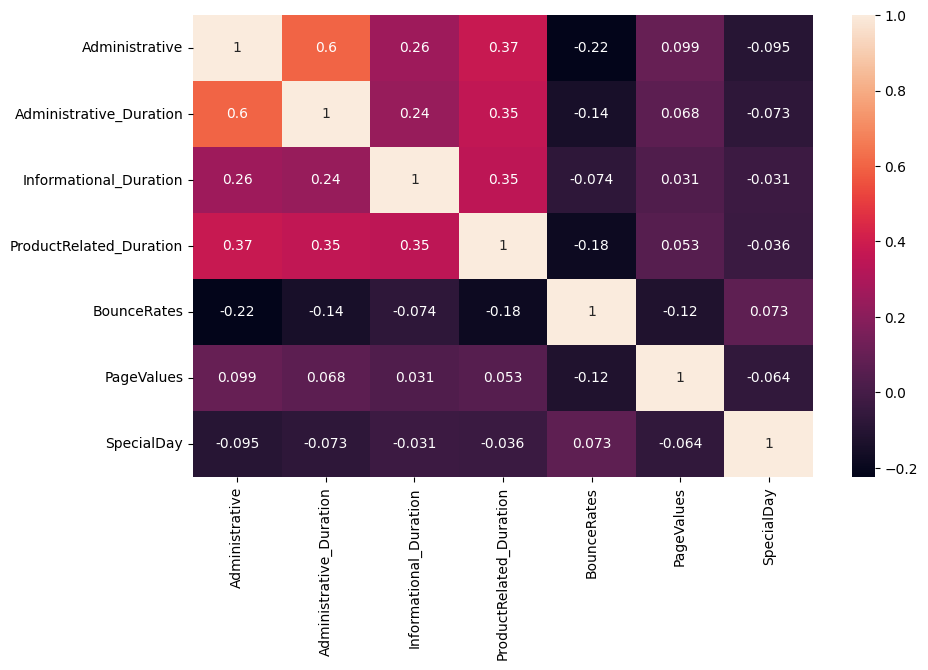

In [25]:
new_corr_matrix = round(new_num_set.corr(), 3)

plt.figure(figsize=(10,6))
sns.heatmap(new_corr_matrix, annot=True)
plt.show()

In [26]:
online_set = pd.concat([new_num_set, obj_set], axis = 1)

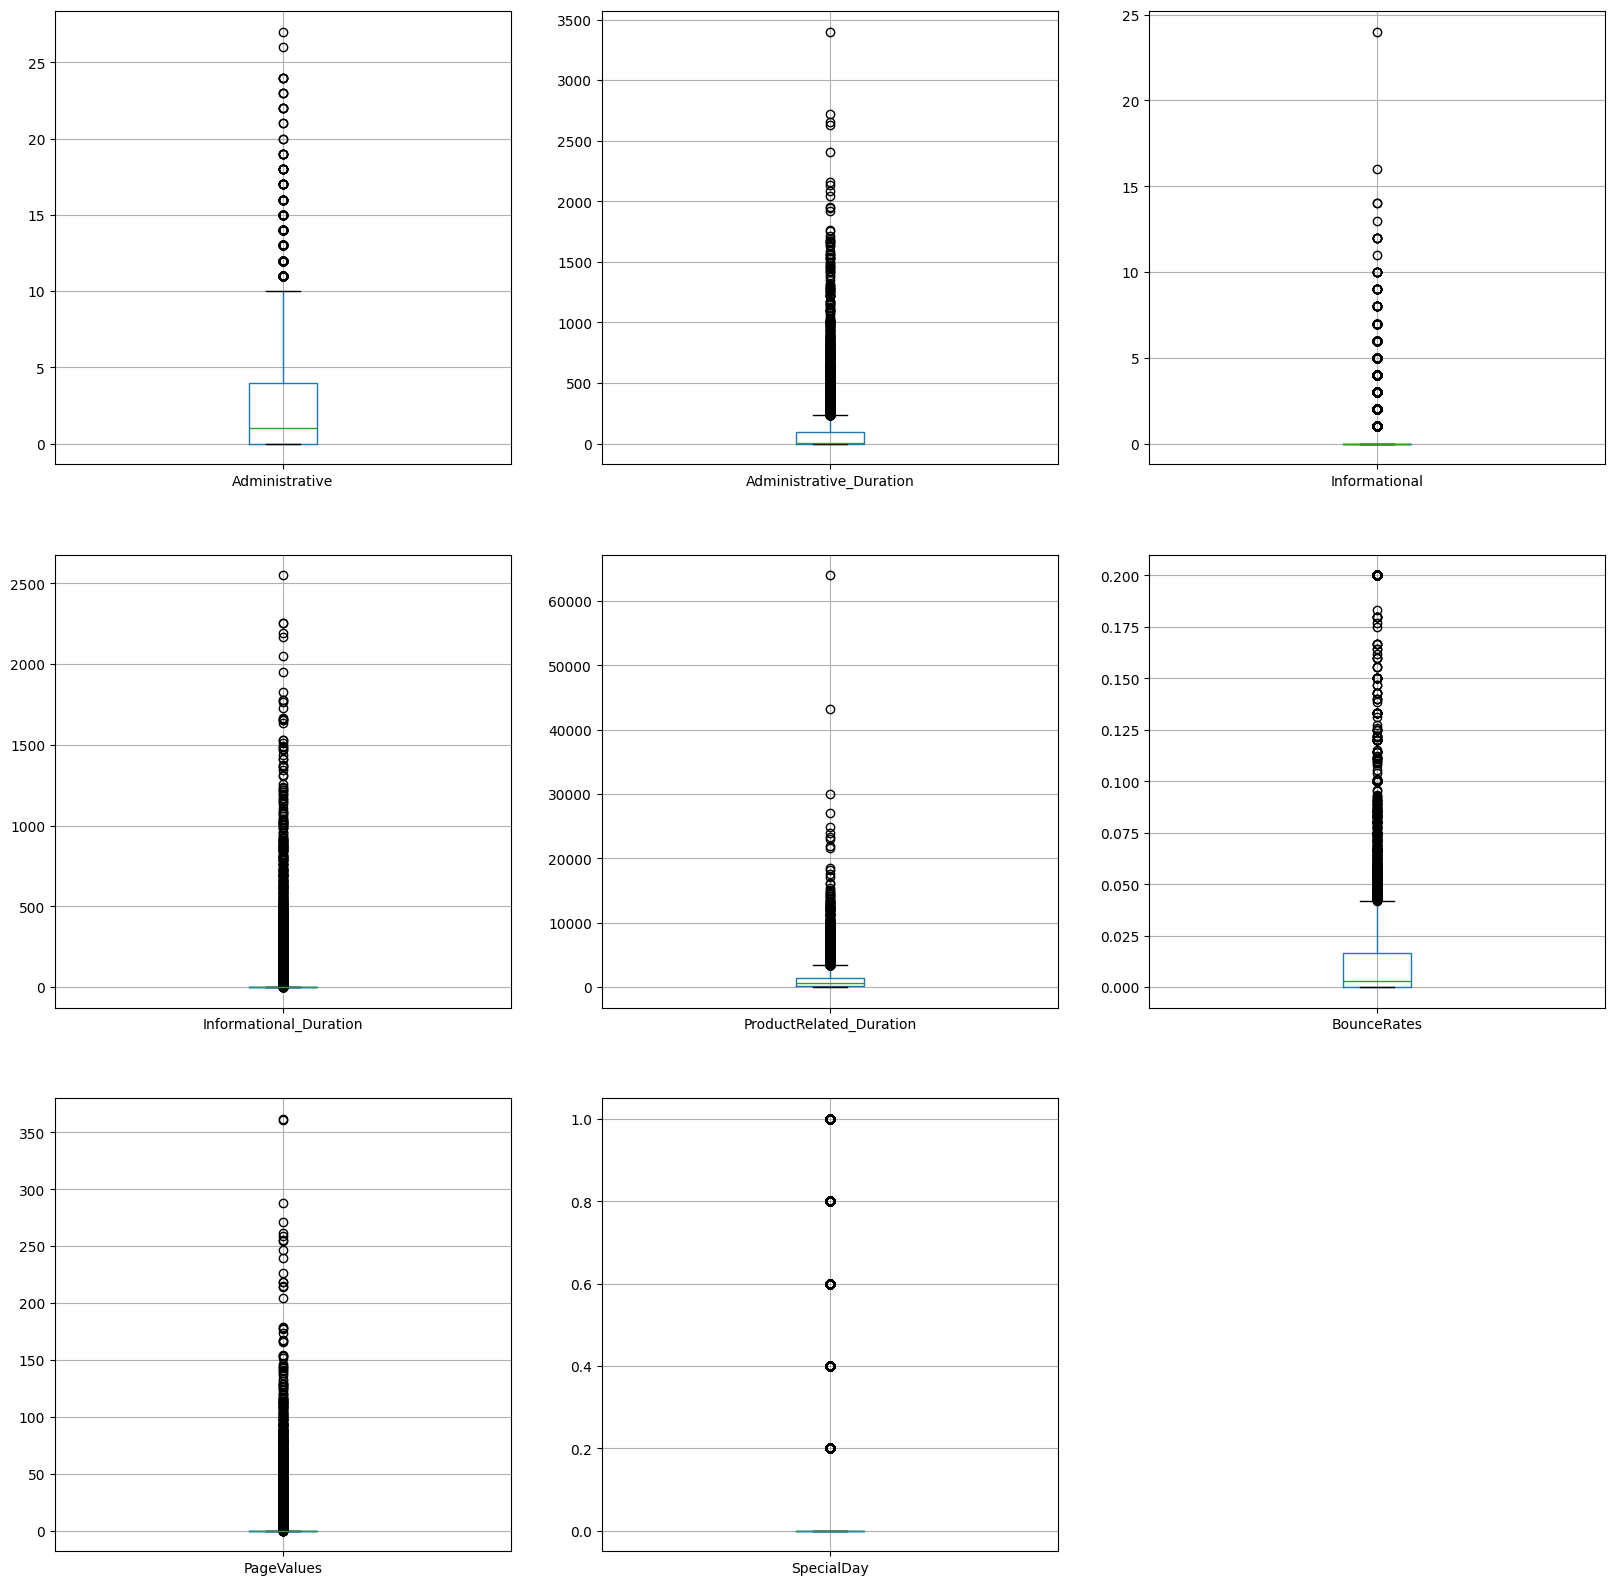

In [27]:
plt.figure(figsize=(20,20))
for i, col in enumerate(['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
       'ProductRelated_Duration', 'BounceRates', 'PageValues', 'SpecialDay'], start=1):
    plt.subplot(3, 3, i)
    num_set.boxplot(col,whis=1.5)

plt.show()

In [28]:
y = online_set['Revenue']
x = online_set.drop(['Revenue'], axis=1)

In [29]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=2, stratify=y)

In [30]:
x_train.head()

,Administrative,Administrative_Duration,Informational_Duration,ProductRelated_Duration,BounceRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
10568,4,22.916667,0.0,221.250000,0.014815,0.000000,0.0,Nov,2,2,1,2,Returning_Visitor,False
2322,4,38.500000,308.0,582.000000,0.000000,0.000000,0.0,May,2,2,2,13,Returning_Visitor,True
9370,4,42.000000,28.5,1367.000000,0.000000,0.000000,0.0,Nov,2,2,3,2,Returning_Visitor,False
11725,1,32.250000,0.0,434.583333,0.011765,0.000000,0.0,Dec,3,2,1,2,Returning_Visitor,False
10137,11,570.250000,0.0,1728.250000,0.006667,22.425768,0.0,Nov,2,2,1,2,Returning_Visitor,False


In [31]:
y_train.head()

,Revenue
10568,False
2322,False
9370,False
11725,False
10137,True


In [32]:
y_train.replace({"False": 0, "True": 1}, inplace=True)
y_test.replace({"False": 0, "True": 1}, inplace=True)

/tmp/ipykernel_2135/886500829.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train.replace({"False": 0, "True": 1}, inplace=True)
/tmp/ipykernel_2135/886500829.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test.replace({"False": 0, "True": 1}, inplace=True)


In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

In [34]:
dum_obj_set = pd.get_dummies(obj_set)

In [35]:
scaler = StandardScaler()
scaled_num_set = scaler.fit_transform(num_set)
num_set = pd.DataFrame(scaled_num_set, columns=num_set.columns)
x_train_transform = pd.concat([num_set.reset_index(drop=True), dum_obj_set.reset_index(drop=True)], axis=1)

In [36]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
encode_y_train = le.fit_transform(y_train)
y_train_transform = pd.DataFrame(encode_y_train)

In [37]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [38]:
num_ft = x_train.select_dtypes(include=['int64', 'float64']).columns
obj_ft = x_train.select_dtypes(include=['object']).columns

In [39]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_ft),
        ('cat', categorical_transformer, obj_ft)])

In [40]:
from pandas import set_option
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, NuSVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier

In [41]:
classifiers = [
    LogisticRegression(),
    SVC(kernel='rbf', C=0.025, probability=True),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    GradientBoostingClassifier(),
    XGBClassifier(),
    LGBMClassifier(),
    MLPClassifier()
    ]

In [42]:
for classifier in classifiers:
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', classifier)
                            ])
    pipe.fit(x_train, y_train)
    print(classifier)
    print('Model score: %.3f' % pipe.score(x_test, y_test))

# Display classification report for all the models for model selection.
    y_pred = pipe.predict(x_test)
    results = confusion_matrix(y_test, y_pred)
    print('Confusion Matrix: ')
    print(results)
    print('Classification Report: ')
    print(classification_report(y_test, y_pred))

LogisticRegression()
Model score: 0.879
Confusion Matrix: 
[[2032   52]
 [ 247  135]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.72      0.35      0.47       382

    accuracy                           0.88      2466
   macro avg       0.81      0.66      0.70      2466
weighted avg       0.87      0.88      0.86      2466

SVC(C=0.025, probability=True)
Model score: 0.874
Confusion Matrix: 
[[2051   33]
 [ 278  104]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.88      0.98      0.93      2084
           1       0.76      0.27      0.40       382

    accuracy                           0.87      2466
   macro avg       0.82      0.63      0.67      2466
weighted avg       0.86      0.87      0.85      2466

DecisionTreeClassifier()
Model score: 0.862
Confusion Matrix: 
[[1915  169]
 [ 171  211]]
Classification Report: 
  

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


MLPClassifier()
Model score: 0.881
Confusion Matrix: 
[[1963  121]
 [ 173  209]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      2084
           1       0.63      0.55      0.59       382

    accuracy                           0.88      2466
   macro avg       0.78      0.74      0.76      2466
weighted avg       0.87      0.88      0.88      2466



/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [43]:
gb_class = GradientBoostingClassifier()
pipe_gb = Pipeline(steps=[('preprocessor', preprocessor),
                       ('gb_class', GradientBoostingClassifier())
                      ])
pipe_gb.fit(x_train, y_train)
print(gb_class)
print('Model score: %.3f' % pipe_gb.score(x_test, y_test))

# Display classification report for all the models for model selection.
y_pred_gb = pipe_gb.predict(x_test)
results_gb = confusion_matrix(y_test, y_pred_gb)
print('Confusion Matrix: ')
print(results_gb)
print('Classification Report: ')
print(classification_report(y_test, y_pred_gb))

GradientBoostingClassifier()
Model score: 0.902
Confusion Matrix: 
[[2003   81]
 [ 161  221]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      2084
           1       0.73      0.58      0.65       382

    accuracy                           0.90      2466
   macro avg       0.83      0.77      0.79      2466
weighted avg       0.90      0.90      0.90      2466



In [44]:
num_set = x_train.select_dtypes(include=['int64', 'float64'])
obj_set = x_train.select_dtypes(include=['object'])
dum_obj_set = pd.get_dummies(obj_set)

In [45]:
scaler = StandardScaler()
scaled_num_set = scaler.fit_transform(num_set)
num_set = pd.DataFrame(scaled_num_set, columns=num_set.columns)
x_train_transform = pd.concat([num_set.reset_index(drop=True), dum_obj_set.reset_index(drop=True)], axis=1)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
encode_y_train = le.fit_transform(y_train)
y_train_transform = pd.DataFrame(encode_y_train)

In [46]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(sampling_strategy='auto', k_neighbors=2, random_state=100)
x_train_smote, y_train_smote = sm.fit_resample(x_train_transform, y_train_transform)

/usr/local/lib/python3.13/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/tmp/ipykernel_2135/3008883777.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= ser_rank.values, y = ser_rank.index, palette='deep')


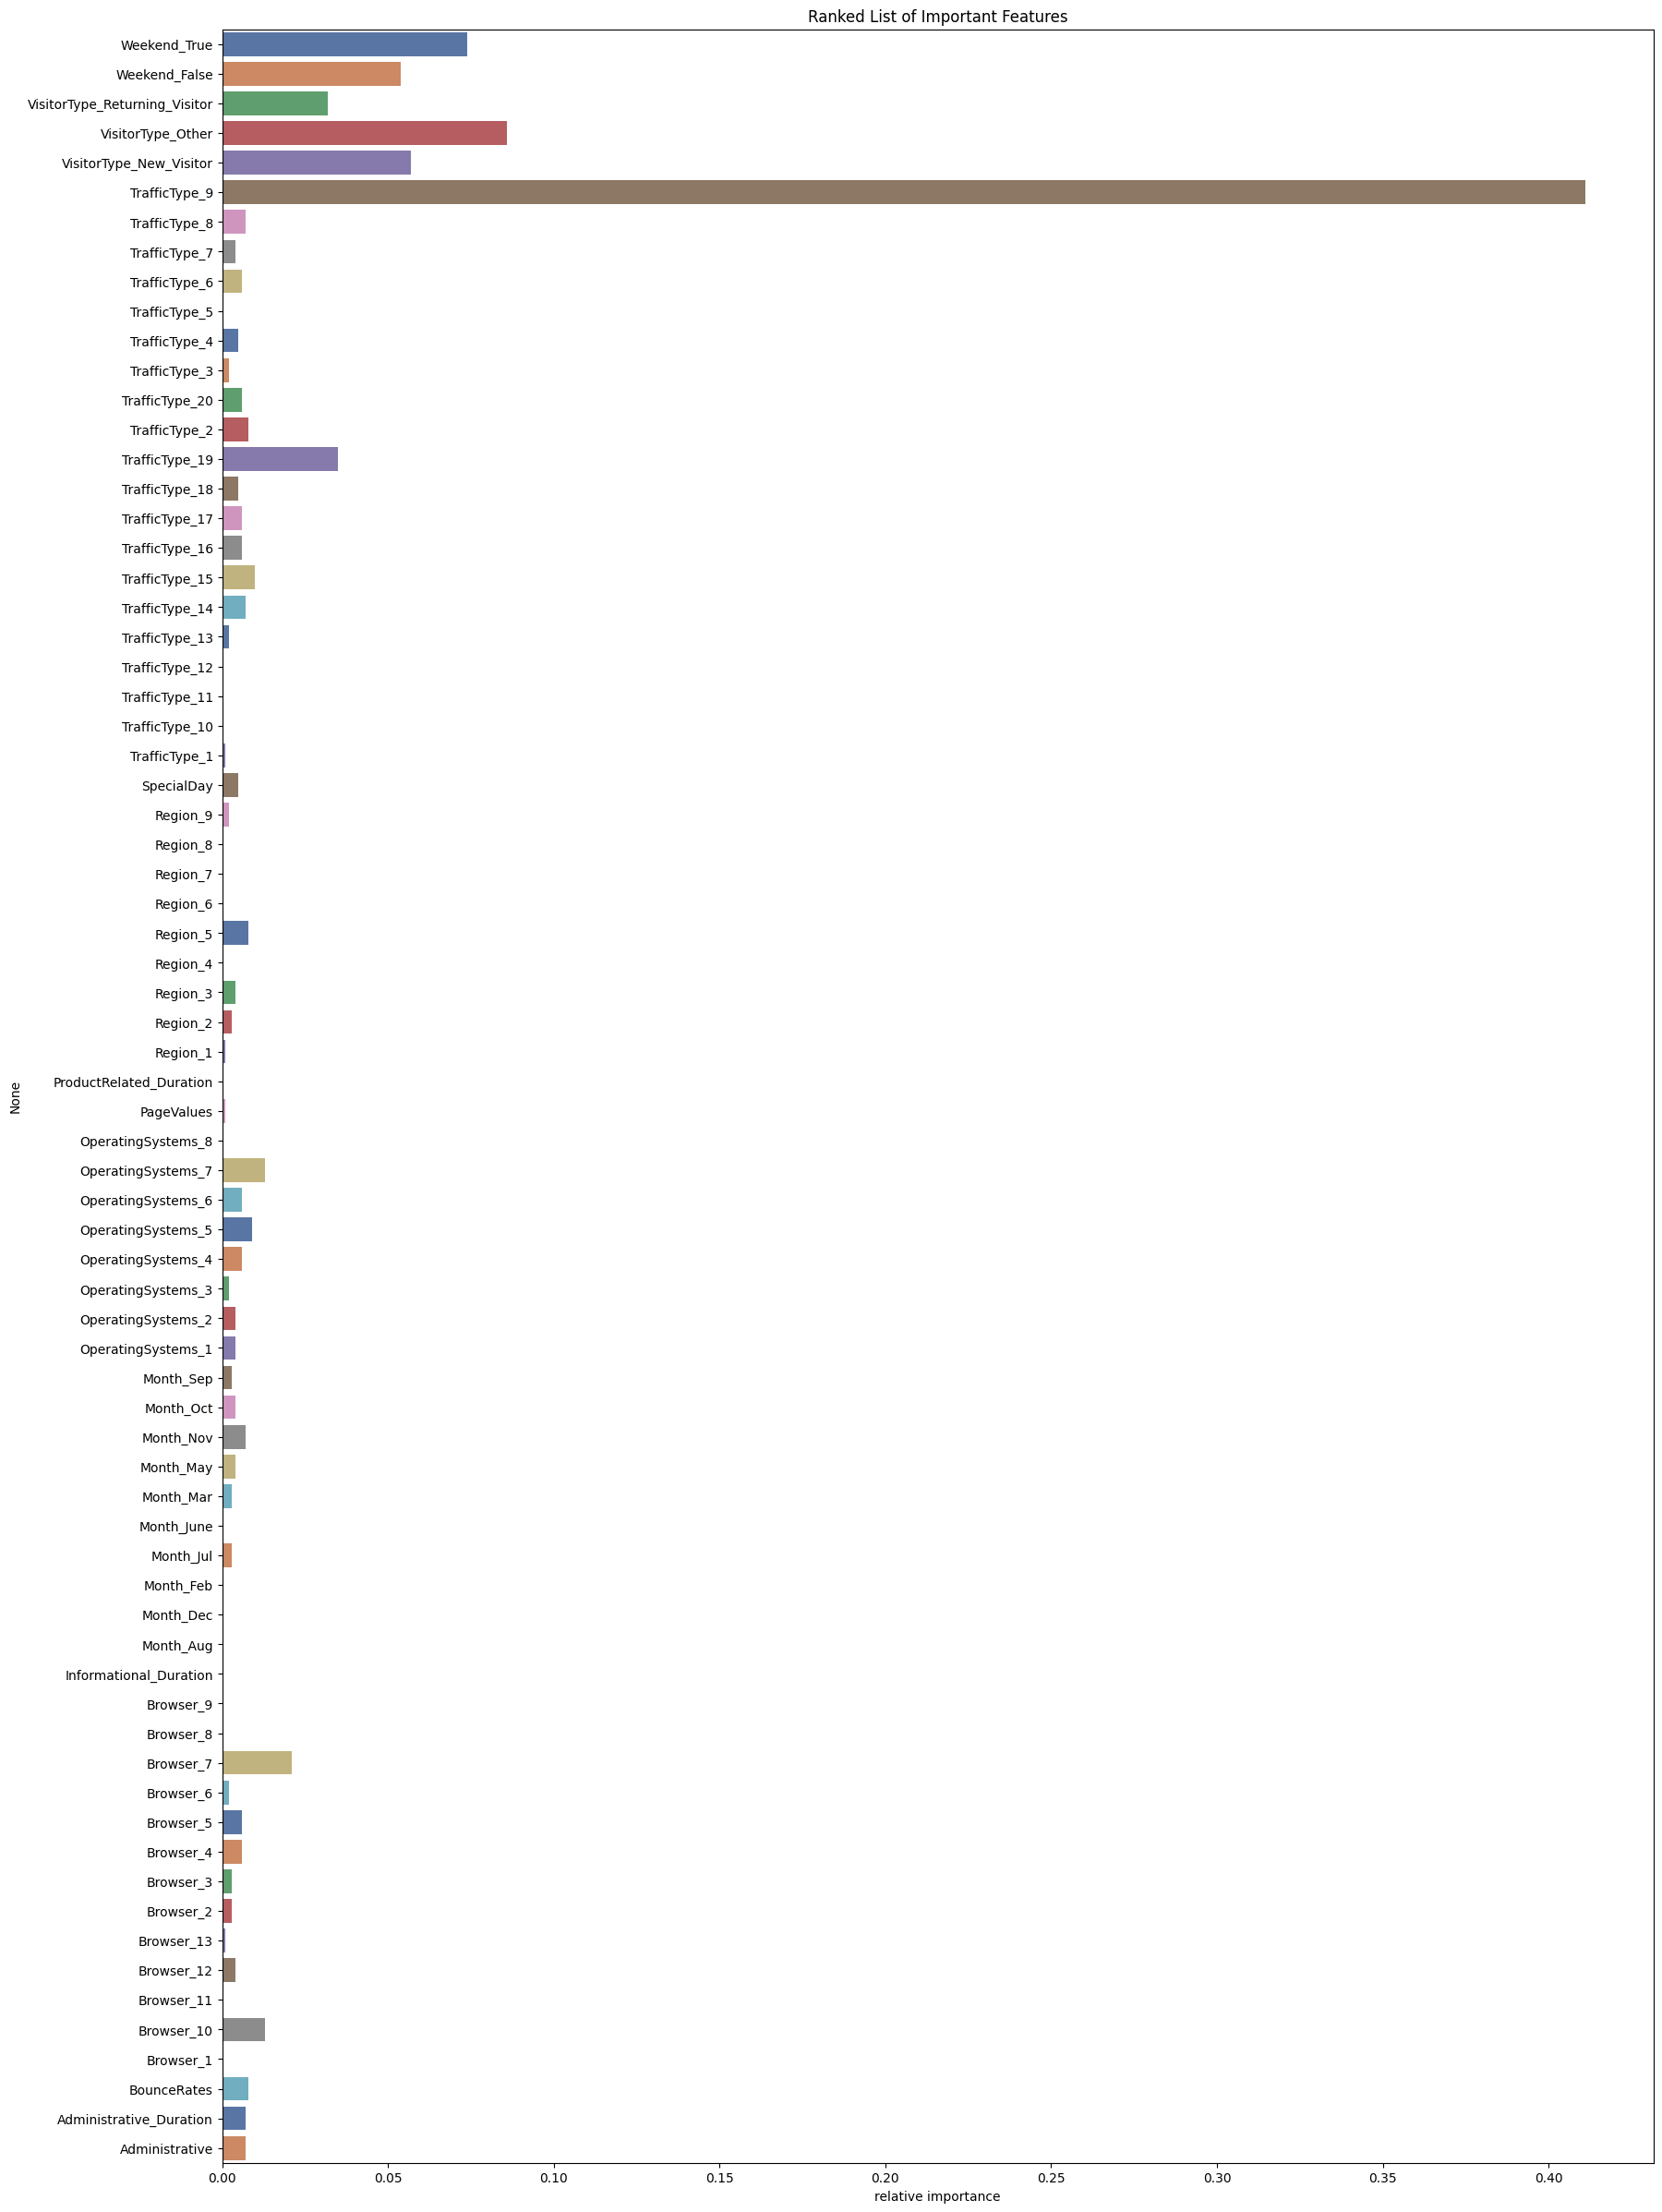

In [47]:
rfc = RandomForestClassifier()
rfc.fit(x_train_smote, y_train_smote)

feature_imp = rfc.feature_importances_.round(3)
ser_rank = pd.Series(feature_imp, index=x_train_smote.columns.sort_values(ascending = False))

plt.figure(figsize=(20,30))
sns.barplot(x= ser_rank.values, y = ser_rank.index, palette='deep')
plt.title('Ranked List of Important Features')
plt.xlabel('relative importance')
plt.show()

In [48]:
imp_features = ser_rank.sort_values(ascending=False)
imp_features[:20]

,0
TrafficType_9,0.411
VisitorType_Other,0.086
Weekend_True,0.074
VisitorType_New_Visitor,0.057
Weekend_False,0.054
TrafficType_19,0.035
VisitorType_Returning_Visitor,0.032
Browser_7,0.021
Browser_10,0.013
OperatingSystems_7,0.013


In [50]:
new_obj_set = obj_set.drop(columns=['Region', 'OperatingSystems'])

In [51]:
num_set = x_train.select_dtypes(include=['int64', 'float64'])
obj_set = new_obj_set

In [52]:
from sklearn.metrics import accuracy_score, classification_report
for classifier in classifiers:
    model = classifier
    model.fit(x_train_smote, y_train_smote)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    print("Classifier:", type(model).__name__)
    print("Accuracy:   %.3f" % accuracy)
    print("Classification Report:\n", report)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Classifier: LogisticRegression
Accuracy:   0.881
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93      2084
           1       0.63      0.55      0.59       382

    accuracy                           0.88      2466
   macro avg       0.78      0.74      0.76      2466
weighted avg       0.87      0.88      0.88      2466



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Classifier: SVC
Accuracy:   0.881
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93      2084
           1       0.63      0.55      0.59       382

    accuracy                           0.88      2466
   macro avg       0.78      0.74      0.76      2466
weighted avg       0.87      0.88      0.88      2466

Classifier: DecisionTreeClassifier
Accuracy:   0.881
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93      2084
           1       0.63      0.55      0.59       382

    accuracy                           0.88      2466
   macro avg       0.78      0.74      0.76      2466
weighted avg       0.87      0.88      0.88      2466



/usr/local/lib/python3.13/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


...

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


Classifier: LGBMClassifier
Accuracy:   0.881
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93      2084
           1       0.63      0.55      0.59       382

    accuracy                           0.88      2466
   macro avg       0.78      0.74      0.76      2466
weighted avg       0.87      0.88      0.88      2466



/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Classifier: MLPClassifier
Accuracy:   0.881
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93      2084
           1       0.63      0.55      0.59       382

    accuracy                           0.88      2466
   macro avg       0.78      0.74      0.76      2466
weighted avg       0.87      0.88      0.88      2466



/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [53]:
!pip install pyspark -q
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder.appName("Path2Profit-Spark").getOrCreate()

In [54]:
sdf = spark.read.csv("online_shoppers_intention.csv", header=True, inferSchema=True)
sdf.printSchema()
print("rows:", sdf.count())
sdf.groupBy("Revenue").count().show()   # class balance, done in Spark

root
 |-- Administrative: integer (nullable = true)
 |-- Administrative_Duration: double (nullable = true)
 |-- Informational: integer (nullable = true)
 |-- Informational_Duration: double (nullable = true)
 |-- ProductRelated: integer (nullable = true)
 |-- ProductRelated_Duration: double (nullable = true)
 |-- BounceRates: double (nullable = true)
 |-- ExitRates: double (nullable = true)
 |-- PageValues: double (nullable = true)
 |-- SpecialDay: double (nullable = true)
 |-- Month: string (nullable = true)
 |-- OperatingSystems: integer (nullable = true)
 |-- Browser: integer (nullable = true)
 |-- Region: integer (nullable = true)
 |-- TrafficType: integer (nullable = true)
 |-- VisitorType: string (nullable = true)
 |-- Weekend: boolean (nullable = true)
 |-- Revenue: boolean (nullable = true)

rows: 12330
+-------+-----+
|Revenue|count|
+-------+-----+
|   true| 1908|
|  false|10422|
+-------+-----+



In [55]:
# cast target bool -> 0/1 label
sdf = sdf.withColumn("label", F.col("Revenue").cast("integer"))

numeric = ["Administrative","Administrative_Duration","Informational","Informational_Duration",
           "ProductRelated_Duration","BounceRates","PageValues","SpecialDay"]
categorical = ["Month","OperatingSystems","Browser","Region","TrafficType","VisitorType","Weekend"]

# make categoricals strings so the indexer treats them as categories
for c in categorical:
    sdf = sdf.withColumn(c, F.col(c).cast("string"))

In [56]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.classification import GBTClassifier

indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in categorical]
encoders = [OneHotEncoder(inputCol=c+"_idx", outputCol=c+"_oh") for c in categorical]

assembler = VectorAssembler(
    inputCols=numeric + [c+"_oh" for c in categorical],
    outputCol="features_raw")
scaler = StandardScaler(inputCol="features_raw", outputCol="features")

gbt = GBTClassifier(featuresCol="features", labelCol="label", maxIter=50)

pipeline = Pipeline(stages=indexers + encoders + [assembler, scaler, gbt])

In [57]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

train, test = sdf.randomSplit([0.8, 0.2], seed=2)
model = pipeline.fit(train)          # trains on the cluster
preds = model.transform(test)        # lazy until we evaluate/show

for metric in ["accuracy","f1","weightedPrecision","weightedRecall"]:
    ev = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName=metric)
    print(metric, round(ev.evaluate(preds), 3))

preds.select("label","prediction","probability").show(5)

accuracy 0.897
f1 0.894
weightedPrecision 0.892
weightedRecall 0.897
+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|    0|       0.0|[0.94298576971277...|
|    0|       0.0|[0.97797026723332...|
|    0|       0.0|[0.97286788560063...|
|    0|       0.0|[0.96728649958079...|
|    0|       0.0|[0.97286788560063...|
+-----+----------+--------------------+
only showing top 5 rows


In [58]:
preds.select("label","prediction").write.mode("overwrite").parquet("preds_parquet/")